# NutriVida · recorrido reproducible del análisis

Este notebook resume el recorrido desde el Excel original hasta un pronóstico de seis meses. Primero se revisan los datos, después se aplican las decisiones de limpieza, se evalúan los modelos con meses conocidos y finalmente se presenta el pronóstico.

El código operativo no se duplica: las reglas se importan desde `limpieza_datos.py` y los resultados trazables se leen de `resultados/Pronostico_NutriVida_2026_FINAL.xlsx`.

## 1. Preparación

La celda encuentra la raíz del proyecto tanto al ejecutarse desde la carpeta principal como desde `notebooks/`.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

RAIZ = Path.cwd()
if not (RAIZ / "Datos_NutriVida.xlsx").exists():
    RAIZ = RAIZ.parent
sys.path.insert(0, str(RAIZ))

from limpieza_datos import limpiar_tablas_nuevas, validar_plantilla

ARCHIVO_DATOS = RAIZ / "Datos_NutriVida.xlsx"
ARCHIVO_RESULTADO = RAIZ / "resultados" / "Pronostico_NutriVida_2026_FINAL.xlsx"
print("Datos:", ARCHIVO_DATOS.name)
print("Resultado:", ARCHIVO_RESULTADO.relative_to(RAIZ))

Datos: Datos_NutriVida.xlsx
Resultado: resultados/Pronostico_NutriVida_2026_FINAL.xlsx


## 2. Datos recibidos

El archivo contiene cinco hojas. Para otro libro sólo son obligatorias `Ventas Historicas` y `Precios y Costos`, con sus columnas mínimas. Las demás hojas permiten reconciliar el detalle con los consolidados.

In [2]:
errores_plantilla, libro = validar_plantilla(ARCHIVO_DATOS)
assert not errores_plantilla, errores_plantilla
resumen_hojas = []
for hoja in libro.sheet_names:
    tabla = pd.read_excel(libro, sheet_name=hoja)
    resumen_hojas.append({"Hoja": hoja, "Filas": len(tabla), "Columnas": len(tabla.columns)})
display(pd.DataFrame(resumen_hojas))

,Hoja,Filas,Columnas
0,Resumen Gerencia,8,2
1,Ventas Historicas,8114,9
2,Pronostico vs Real,875,5
3,Inventario y Quiebres,875,8
4,Precios y Costos,25,7


## 3. Problemas encontrados y limpieza

- Se retiraron únicamente copias exactas.
- Se homologaron variantes evidentes sin mezclar Ecommerce con Supermercado.
- Se completaron precios vacíos con el catálogo después de comprobar su consistencia.
- Se modelaron unidades negativas como cero porque así reconciliaban con los consolidados.
- Se conservaron unidades vacías y atípicos en el original; los cambios viven en `Unidades_Modelo`.
- Se distinguió un cero explícito de una celda vacía.

In [3]:
ventas_crudas = pd.read_excel(libro, sheet_name="Ventas Historicas")
catalogo = pd.read_excel(libro, sheet_name="Precios y Costos")
ventas_limpias, diagnostico = limpiar_tablas_nuevas(ventas_crudas, catalogo)

etiquetas = {
    "filas_originales": "Filas recibidas",
    "duplicados_retirados": "Copias exactas retiradas",
    "unidades_vacias": "Unidades vacías detectadas",
    "unidades_negativas": "Unidades negativas detectadas",
    "precios_vacios": "Precios vacíos detectados",
    "atipicos_altos_ajustados": "Atípicos ajustados sólo para modelar",
    "filas_limpias": "Filas después de limpiar",
}
display(pd.DataFrame([
    {"Comprobación": etiqueta, "Cantidad": diagnostico[clave]}
    for clave, etiqueta in etiquetas.items()
]))

display(pd.DataFrame({
    "Comprobación final": ["Claves repetidas", "Precios vacíos", "Unidades negativas para modelar", "Unidades vacías para modelar"],
    "Cantidad": [
        ventas_limpias.duplicated(["Fecha", "SKU", "Canal", "Region"]).sum(),
        ventas_limpias["Precio_Unitario_USD"].isna().sum(),
        ventas_limpias["Unidades_Modelo"].lt(0).sum(),
        ventas_limpias["Unidades_Modelo"].isna().sum(),
    ],
}))

,Comprobación,Cantidad
0,Filas recibidas,8114
1,Copias exactas retiradas,14
2,Unidades vacías detectadas,28
3,Unidades negativas detectadas,9
4,Precios vacíos detectados,19
5,Atípicos ajustados sólo para modelar,1
6,Filas después de limpiar,8100


,Comprobación final,Cantidad
0,Claves repetidas,0
1,Precios vacíos,0
2,Unidades negativas para modelar,0
3,Unidades vacías para modelar,0


## 4. Método recomendado

1. Estima la demanda normal sin promociones.
2. Aprende qué meses suelen quedar arriba o abajo del promedio de cada SKU.
3. Promedia los dos meses comparables más recientes. Se probó un tercer mes, pero la validación le asignó peso cero.
4. Obtiene la base como `promedio reciente comparable × índice estacional`.
5. Incorpora promoción sólo si el mismo SKU y mes la tuvieron en al menos dos años.
6. Distribuye el total del SKU entre canal y región sin cambiar la suma.

El escenario protegido multiplica el recomendado por 1.08. Es una decisión para reducir faltantes, no una predicción más probable.

## 5. Cómo se evaluó

Se ocultaron periodos de 2025, se pronosticaron usando sólo la historia disponible en cada fecha y se compararon contra la demanda real.

El **error acumulado por cada 100 unidades reales** es:

\[
\frac{\sum |pronóstico-real|}{\sum real}\times 100
\]

Cuenta faltantes y excesos sin permitir que se cancelen. El **balance neto** conserva el signo: negativo significa que el modelo quedó corto y positivo que proyectó de más.

In [4]:
detalle = pd.read_excel(ARCHIVO_RESULTADO, sheet_name="Detalle Validacion")
total_real = detalle["Venta_Real"].sum()
columnas_modelos = {
    "Pronóstico entregado por la empresa": ("Error_Empresa", "Error_Abs_Empresa"),
    "Mismo mes del año anterior": ("Error_Mismo_Mes_Anterior", "Error_Abs_Mismo_Mes_Anterior"),
    "Promedio reciente + estacionalidad": ("Error_Ponderado_Estacional", "Error_Abs_Ponderado_Estacional"),
    "Modelo recomendado": ("Error_Recomendado", "Error_Abs_Recomendado"),
    "Escenario protegido 8%": ("Error_Protegido", "Error_Abs_Protegido"),
}
comparacion = pd.DataFrame([
    {
        "Modelo": modelo,
        "Error por cada 100 unidades reales": detalle[error_abs].sum() / total_real * 100,
        "Balance neto (%)": detalle[error].sum() / total_real * 100,
    }
    for modelo, (error, error_abs) in columnas_modelos.items()
]).sort_values("Error por cada 100 unidades reales")
display(comparacion.style.format({
    "Error por cada 100 unidades reales": "{:.2f}",
    "Balance neto (%)": "{:+.2f}%",
}))

,Modelo,Error por cada 100 unidades reales,Balance neto (%)
3,Modelo recomendado,10.56,-5.35%
4,Escenario protegido 8%,10.61,+2.22%
1,Mismo mes del año anterior,11.59,-5.57%
2,Promedio reciente + estacionalidad,11.71,-1.45%
0,Pronóstico entregado por la empresa,19.22,+7.69%


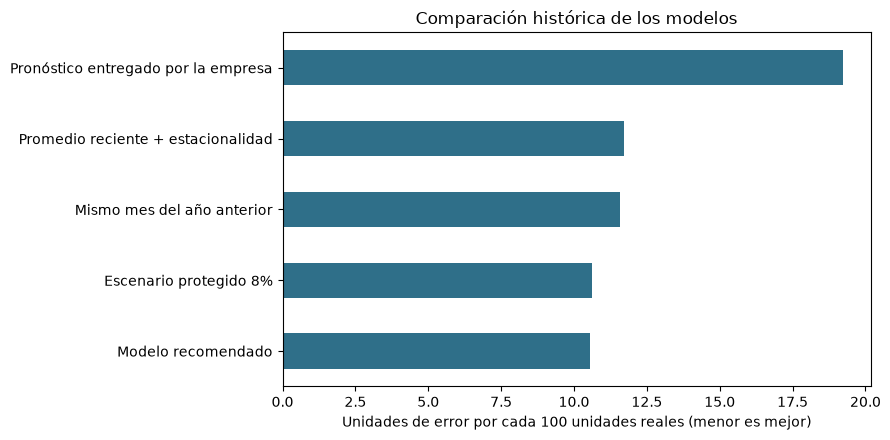

In [5]:
ax = comparacion.sort_values("Error por cada 100 unidades reales").plot.barh(
    x="Modelo", y="Error por cada 100 unidades reales", legend=False,
    color="#2f6f89", figsize=(9, 4.5),
)
ax.set_title("Comparación histórica de los modelos")
ax.set_xlabel("Unidades de error por cada 100 unidades reales (menor es mejor)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 6. Resultado del pronóstico

El resultado central usa promociones recurrentes porque no se recibió un calendario futuro confirmado. Sin promociones futuras, recomendado y protegido permanecen separados.

In [6]:
mensual = pd.read_excel(ARCHIVO_RESULTADO, sheet_name="Resumen Mensual")
mensual["Fecha"] = pd.to_datetime(mensual["Fecha"])
mensual_mostrado = mensual.rename(columns={
    "Base_Sin_Promocion": "Base sin promoción",
    "Recomendado": "Pronóstico recomendado",
    "Protegido": "Escenario protegido",
})
columnas = ["Fecha", "Base sin promoción", "Pronóstico recomendado", "Escenario protegido"]
display(mensual_mostrado[columnas].style.format({
    "Base sin promoción": "{:,.0f}",
    "Pronóstico recomendado": "{:,.0f}",
    "Escenario protegido": "{:,.0f}",
}))
print(f"Total recomendado: {mensual['Recomendado'].sum():,.0f} unidades")
print(f"Total protegido: {mensual['Protegido'].sum():,.0f} unidades")

,Fecha,Base sin promoción,Pronóstico recomendado,Escenario protegido
0,2026-01-01 00:00:00,"177,099","182,716","197,333"
1,2026-02-01 00:00:00,"182,564","186,571","201,496"
2,2026-03-01 00:00:00,"193,077","198,055","213,899"
3,2026-04-01 00:00:00,"201,528","206,197","222,693"
4,2026-05-01 00:00:00,"216,171","223,769","241,671"
5,2026-06-01 00:00:00,"222,065","227,512","245,713"


Total recomendado: 1,224,820 unidades
Total protegido: 1,322,806 unidades


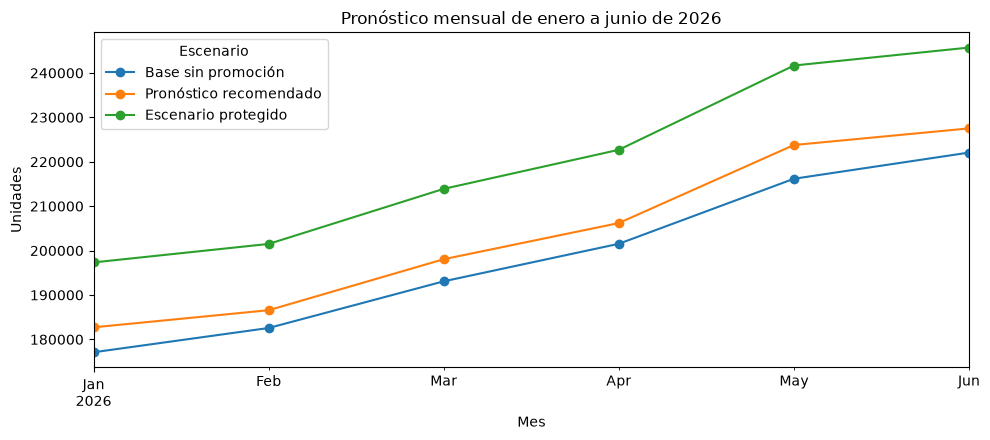

In [7]:
ax = mensual_mostrado.set_index("Fecha")[[
    "Base sin promoción", "Pronóstico recomendado", "Escenario protegido"
]].plot(marker="o", figsize=(10, 4.5))
ax.set_title("Pronóstico mensual de enero a junio de 2026")
ax.set_xlabel("Mes")
ax.set_ylabel("Unidades")
ax.legend(title="Escenario")
plt.tight_layout()
plt.show()

## 7. Robustez del escenario protegido

Agregar 8% reduce el riesgo de quedarse corto, pero puede aumentar el excedente. Por eso se comprobó por SKU en lugar de asumir que ayuda a todos por igual.

In [8]:
robustez = pd.read_excel(ARCHIVO_RESULTADO, sheet_name="Robustez SKU")
display(pd.DataFrame({
    "Comprobación": ["SKU evaluados", "SKU donde reduce faltantes", "SKU donde también reduce el error total"],
    "Cantidad": [
        len(robustez),
        int(robustez["Proteccion_Reduce_Subestimacion"].sum()),
        int(robustez["Proteccion_Mejora_WAPE"].sum()),
    ],
}))

vista = robustez[[
    "SKU", "Producto", "Categoria", "WAPE_Recomendado_pct",
    "WAPE_Protegido_pct", "Subestimacion_Recomendado_pct",
    "Subestimacion_Protegido_pct",
]].rename(columns={
    "WAPE_Recomendado_pct": "Error recomendado por cada 100",
    "WAPE_Protegido_pct": "Error protegido por cada 100",
    "Subestimacion_Recomendado_pct": "Faltante recomendado (%)",
    "Subestimacion_Protegido_pct": "Faltante protegido (%)",
})
display(vista.sort_values("Error recomendado por cada 100", ascending=False).head(10).style.format({
    "Error recomendado por cada 100": "{:.2f}",
    "Error protegido por cada 100": "{:.2f}",
    "Faltante recomendado (%)": "{:.2f}%",
    "Faltante protegido (%)": "{:.2f}%",
}))

,Comprobación,Cantidad
0,SKU evaluados,25
1,SKU donde reduce faltantes,25
2,SKU donde también reduce el error total,13


,SKU,Producto,Categoria,Error recomendado por cada 100,Error protegido por cada 100,Faltante recomendado (%),Faltante protegido (%)
1,SKU-1007,Galleta Avena 180g,Galletas,16.89,13.75,15.39%,10.37%
7,SKU-1021,Azucar 1kg,Despensa,16.19,11.38,16.19%,10.43%
0,SKU-1014,Agua Saborizada 500ml,Bebidas,15.58,14.37,13.43%,9.28%
2,SKU-1011,Snack Mix 120g,Galletas,15.04,12.98,12.44%,7.81%
20,SKU-1024,Atun Lomitos 160g,Despensa,13.33,9.28,11.49%,5.86%
11,SKU-1009,Galleta Salada 150g,Galletas,12.41,10.37,10.14%,5.44%
12,SKU-1019,Fideos Spaghetti 400g,Despensa,11.84,10.30,10.67%,6.27%
13,SKU-1002,Yogurt Frutado Pack 4,Lacteos,11.68,10.23,10.74%,6.41%
5,SKU-1006,Manjar 400g,Lacteos,10.88,11.95,8.57%,5.36%
18,SKU-1012,Jugo Naranja 1L,Bebidas,10.68,9.53,7.24%,2.82%


## 8. Conclusiones y límites

- El modelo recomendado redujo el error histórico agregado frente al pronóstico entregado por la empresa.
- El escenario protegido reduce faltantes, pero no necesariamente mejora la precisión de todos los SKU.
- Una promoción futura confirmada debe reemplazar la inferencia por recurrencia.
- La pausa de Azúcar es reversible: nuevos datos positivos reactivan el SKU.
- Sin edad de los lotes no puede calcularse la merma sólo con vida útil.
- Precio y margen permiten proyectar dinero, pero no cambian unidades sin datos de elasticidad.

Para explorar filtros, ajustes y archivos nuevos, ejecuta `streamlit run dashboard.py`.